# 2025/26-XAI-LABS
Sign-off all exercises except for the one which says optional. 

For the record keeping please return a Jupyter notebook as a submission in Canvas, to make the grading easier for us.

**Group No:** Project -Assignment 27

**Student Name**: Alexander Diyanov Kralev

**Student Name**: Airidas Radzvilas


# Lecture 1
The following set of exercises are related to the Lecture 1.
## Feature Importance
### Exercises on Permutation Feature Importance
In this exercise we apply permutation feature importance to a real world dataset. We attempt is using two ways.
1. Using our own basic implmenattion of the algorithm
2. Using the exiting libraries

**Acknowledgement** : Some code is generated using chatgpt but it is tested for any errors.

In [1]:
# First of all import the required packages
# Load required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

We'll use the 'breast_cancer' dataset from 'sklearn.datasets', which is a binary classification problem.

In [2]:
# Load dataset
data =load_breast_cancer()
X=data.data
y=data.target

Split data into train and test. Fix the random state seed and also use 20% for testing

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Train a Model
One can use any classifier to train the model. Here we will use **random forest** classifier

In [4]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# Lets us check how well our model is doing
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



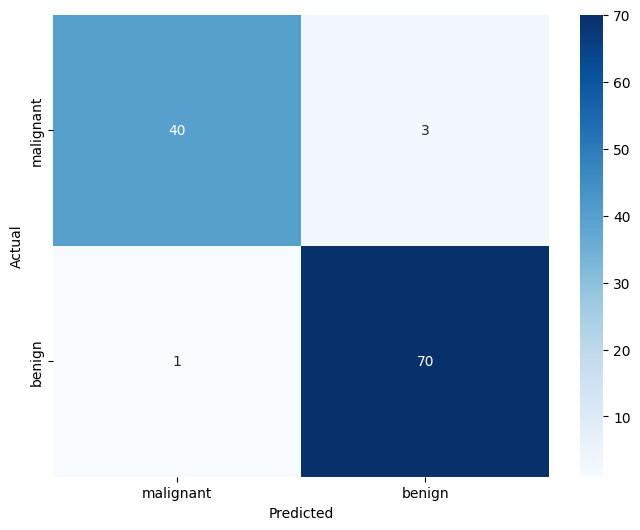

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Exercise 1
Provide an implementation of the basic algorithm on permutation feature importance.
*Note:*You will be graded on storage, copying, and handling of the random state.

In [7]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

def permutation_importance(model, X_test, y_test, metric = accuracy_score, n_repeats = 10):
    baseline = metric(y_test, model.predict(X_test))
    random_state = 42
    rng = np.random.default_rng(random_state)
    results = {}
  # do something with baseline accuracy
    for j in range(X_test.shape[1]):        # OUTER: features, use j
        scores = []                          # reset per feature, BEFORE the repeat loop
        for _ in range(n_repeats):           # INNER: repeats, use _
            X_perm = X_test.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])
            acc = metric(y_test, model.predict(X_perm))
            scores.append(baseline - acc)
        results[data.feature_names[j]] = (np.mean(scores), np.std(scores))   # store BOTH
    return results
results = permutation_importance(clf, X_test, y_test,n_repeats = 30)

for name, (mean, std) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    print(f"{str(name):<28} {mean:+.4f} ± {std:.4f}")

  # Where will you store computed importance

  # Think about doing it for all features.
  # Think about shuffling parts of a column
  #  Compute accuracy after shuffling
  # Compute the difference from the baseline
  # Return the accuracy.

# compare r.importances_mean to your dict's values

worst radius                 +0.0038 ± 0.0043
worst area                   +0.0038 ± 0.0100
mean area                    +0.0035 ± 0.0043
worst texture                +0.0032 ± 0.0042
mean texture                 +0.0023 ± 0.0039
mean concavity               +0.0012 ± 0.0030
worst concavity              +0.0012 ± 0.0030
worst compactness            +0.0009 ± 0.0026
worst smoothness             +0.0003 ± 0.0016
mean radius                  +0.0000 ± 0.0000
mean perimeter               +0.0000 ± 0.0000
mean smoothness              +0.0000 ± 0.0000
mean compactness             +0.0000 ± 0.0000
mean symmetry                +0.0000 ± 0.0000
mean fractal dimension       +0.0000 ± 0.0000
radius error                 +0.0000 ± 0.0000
texture error                +0.0000 ± 0.0000
perimeter error              +0.0000 ± 0.0000
area error                   +0.0000 ± 0.0000
smoothness error             +0.0000 ± 0.0000
compactness error            +0.0000 ± 0.0000
concavity error              +0.00

### Exercise 2:
In this exercise you will test and compare your implemntation. As a baseline we use the implemnattion from SKLEARN. Create tests to test your implementation thorougly. You will graded on aspects such as improving the computational feasibility, reducing the impact of randomization, efficient storage and retrivel of results, and creation of visulization.

In [8]:
# Use this block to write your code.
from sklearn.inspection import permutation_importance
import pandas as pd

# --- PFI with accuracy (matches your manual version) ---
acc_result = permutation_importance(
    clf, X_test, y_test,
    n_repeats=10,            # shuffle 10x per feature, then average (your manual version did 1)
    random_state=42,         # same role as your rng seed
    scoring="accuracy"
)

acc_importances = pd.Series(
    acc_result.importances_mean, index=data.feature_names
).sort_values(ascending=False)

print("=== PFI with accuracy ===")
print(acc_importances)



=== PFI with accuracy ===
mean texture               0.003509
mean area                  0.003509
worst radius               0.003509
worst texture              0.002632
worst area                 0.002632
mean concavity             0.000877
worst concavity            0.000877
mean symmetry              0.000000
mean fractal dimension     0.000000
radius error               0.000000
mean compactness           0.000000
mean radius                0.000000
mean smoothness            0.000000
mean perimeter             0.000000
symmetry error             0.000000
area error                 0.000000
texture error              0.000000
perimeter error            0.000000
concave points error       0.000000
concavity error            0.000000
smoothness error           0.000000
compactness error          0.000000
worst compactness          0.000000
fractal dimension error    0.000000
worst smoothness           0.000000
worst perimeter            0.000000
worst fractal dimension    0.000000
wo

### How to interpret
**Zero Importance:** A feature with an importance close to zero has little to no impact on the model's predictive performance. In the context of permutation importance, this means that shuffling the feature values (randomizing them) doesn't really change the model's performance.

- **Follow-up Action:** Features with zero importance might not be necessary for the model. You could consider removing them in subsequent model training to simplify the model without sacrificing performance. However, it's essential to re-evaluate the model after removal to ensure no significant performance drop.

**Positive Importance:** This indicates that the feature has a positive effect on the model's predictive performance. Randomizing this feature's values (through permutation) worsens the model's performance.

- **Follow-up Action:** Features with positive importance are valuable to the model. They should be retained in the dataset. Further, understanding why these features are important can provide insights into the problem domain.

**Negative Importance:** A negative importance suggests that the random permutation of this feature actually improved the model's performance. This is counterintuitive and could indicate that the feature might be misleading the model when it's not permuted. However, it can also be due to noise or randomness, especially if the negative value is not significant.

- ** Follow-up Action:** It's essential to investigate features with negative importance. If consistent across multiple runs or models, consider whether the feature is correctly constructed or whether there might be data leakage. Depending on the analysis, you might choose to remove or modify such features.

**General Tips:**
- Before making decisions based solely on permutation importance, consider other methods of feature importance or selection to get a holistic view.
- Domain knowledge is invaluable. Feature importance should be interpreted in the context of the problem domain. For instance, even if a feature has low importance, it might be kept for reasons of interpretability or domain significance.
- Always retrain and re-evaluate the model after making changes based on feature importance to ensure that the model's performance remains consistent or improves.

### (Advanced)Exercise 3
- Using the above guideline interpret the feature importance plot.
- What will be the impact of using different classifier? The question can be answered by running a comparative study for different classifier.

-Answer: the impact is that feature importance is model-specific, a different classifier produces different importances (in magnitude and ranking) because each model uses features differently, especially correlated ones, which means feature-importance conclusions only hold for the model you measured and you should compare across models for a robust view. The two models broadly agree on which features carry signal — both rank the tumor size and shape features (worst area, concave points, perimeter) near the top — but their importance rankings aren't perfectly aligned. The RandomForest concentrates its importance sharply on a few features, whereas logistic regression distributes it more evenly across the correlated features.

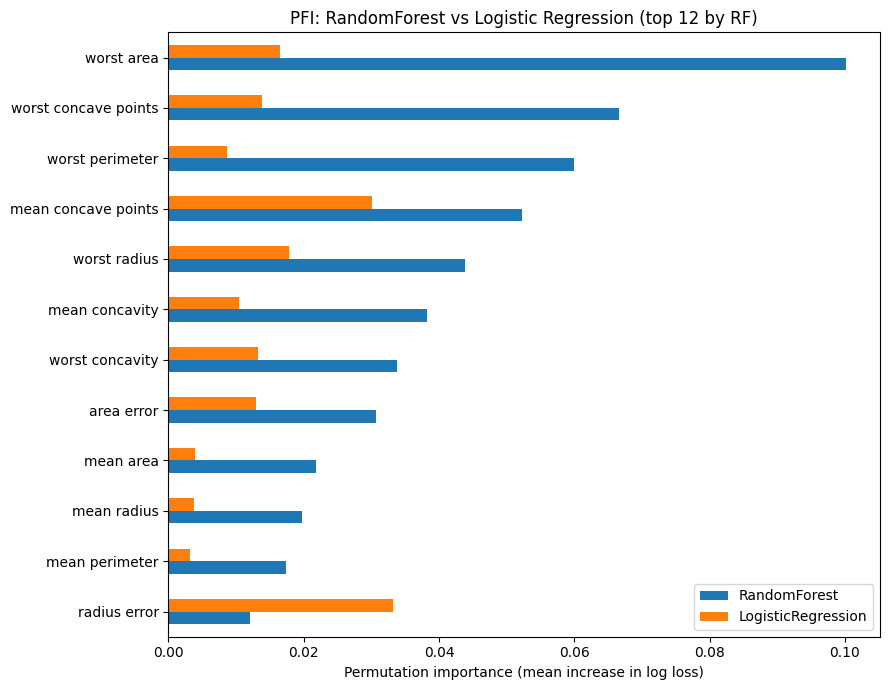

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance as sk_pfi
import pandas as pd, matplotlib.pyplot as plt

# Contrasting model: logistic regression (linear) on the same split.
# Wrapped with a scaler because linear models need standardized features for a fair comparison.
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=42))
logreg.fit(X_train, y_train)

# PFI with log loss for both models
rf_imp = sk_pfi(clf,    X_test, y_test, n_repeats=10, random_state=42, scoring="neg_log_loss")
lr_imp = sk_pfi(logreg, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_log_loss")

compare = pd.DataFrame(
    {"RandomForest": rf_imp.importances_mean,
     "LogisticRegression": lr_imp.importances_mean},
    index=data.feature_names
)

# Top 12 by RF importance, plotted side by side
top = compare.sort_values("RandomForest", ascending=False).head(12)
ax = top.iloc[::-1].plot.barh(figsize=(9, 7))
ax.set_xlabel("Permutation importance (mean increase in log loss)")
ax.set_title("PFI: RandomForest vs Logistic Regression (top 12 by RF)")
plt.tight_layout(); plt.show()

### Exercise 4
Create a dataset with 2 features and a target, such that the pdp of the first feature is flat, but its permutation importance is high. We will use a RandomForest for the model.

**Exercise credit**: https://www.kaggle.com/code/dansbecker/exercise-partial-plots

In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Set a random seed for reproducibility

rng = np.random.default_rng(43)
# Generate synthetic data
n_samples = 1000
X1 = rng.uniform(-1,1, n_samples)
X2 = rng.uniform(-1,1, n_samples)

# Target with interaction: y is only affected by the interaction of X1 and X2
y = X1 * X2

# Create DataFrame
data = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y})

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data[['X1', 'X2']], data['y'], test_size=0.2, random_state=0)


In [15]:
# Initialize and train RandomForest
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


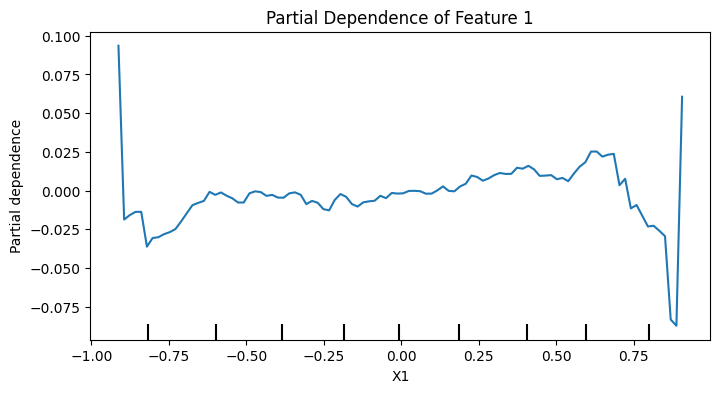

Permutation Importance of Feature 1: 1.94040449812451


In [17]:
# Plot Partial Dependence for Feature 1
fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(model, X_train, features=[0], ax=ax)  # Feature index 0 for X1
plt.title("Partial Dependence of Feature 1")
plt.show()

# Calculate Permutation Importance for Feature 1
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=0)
print("Permutation Importance of Feature 1:", result.importances_mean[0])


### Analyse the results obtained via the code given above.

In this exercise the dataset was built so that the target depends only on the interaction of the two features: y = X1 · X2. Because of this, X1 has no effect on the prediction on its own its effect on y depends entirely on the value of X2. When X2 is positive, increasing X1 increases y, when X2 is negative, increasing X1 decreases y. These two opposing effects are of equal size, and because X2 is symmetric around zero, they cancel each other out when averaged.
The Partial Dependence Plot computes exactly that average: it sweeps X1 across its range while averaging over all values of X2. Since the positive and negative effects cancel, the PDP comes out essentially flat — it reports that changing X1 produces no net change in the prediction. Looking at the PDP alone, you would wrongly conclude that X1 is unimportant.
Contrary to that, the permutation importance is 1.94 really high, showcasing that PFI is not similarly biased as PDP and shows that some effects could be missed by PDP and caught by PFI.

### Exercise 5
In this exercise we will evaluate the impact of feature engineeing on model predictions.
The exercise can be approach from different perspective. However, you can choose the following steps:


*   Choose a data set (see starter code below)
*   build the model
*  generate [ALE plots](https://github.com/blent-ai/ALEPython)
* Apply some feature engineering ( e.g. binning or normalization or any other).
* Build model again with engineerd features
* generate again ALE plots for engineered features
* analyse both graphs (think about magnitude of effect, shape, direction etc).

Starter code is given below:




In [22]:
# load required packages
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split





In [37]:
# load datasets
diabetes_data = load_diabetes()
df = pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names)
df['progression'] = diabetes_data.target
# split data
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('progression', axis=1),
    df['progression'], test_size=0.2, random_state=42)

In [38]:
# Train the model [fee free to choose another one]
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Complete the code from here. You can choose bmi and age as the varibales.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


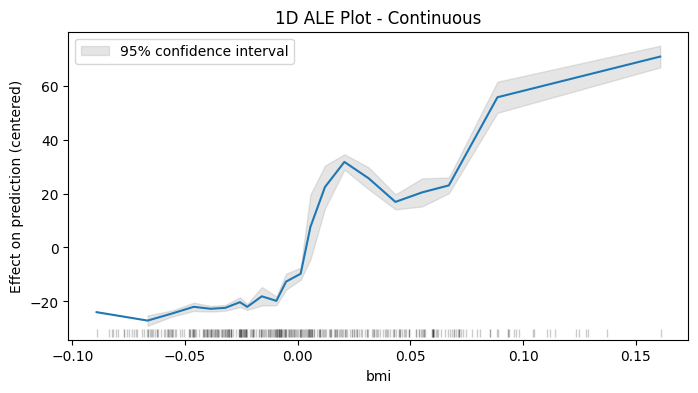

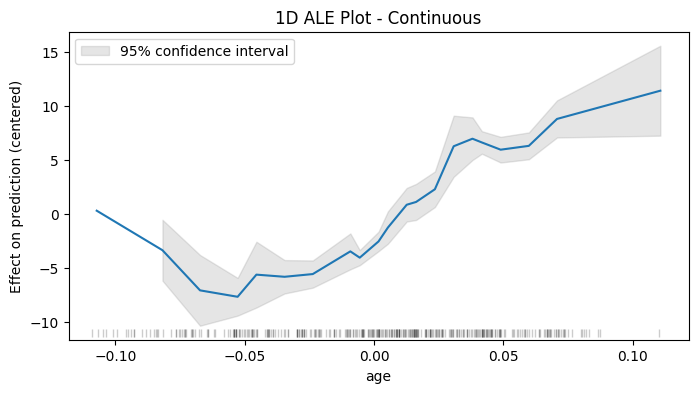

In [39]:
from PyALE import ale
ale_bmi = ale(X=X_train, model=model, feature=["bmi"])
ale_age = ale(X=X_train, model=model, feature=["age"])

In [40]:
df_binned = df.copy()
df_binned['bmi'] = pd.cut(df['bmi'], bins=5, labels=False)
df_binned['age'] = pd.cut(df['age'], bins=5, labels=False)

In [41]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df_binned.drop('progression', axis=1), df_binned['progression'],
    test_size=0.2, random_state=42)

model_binned = RandomForestRegressor(random_state=42)
model_binned.fit(X_train_b, y_train_b)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.


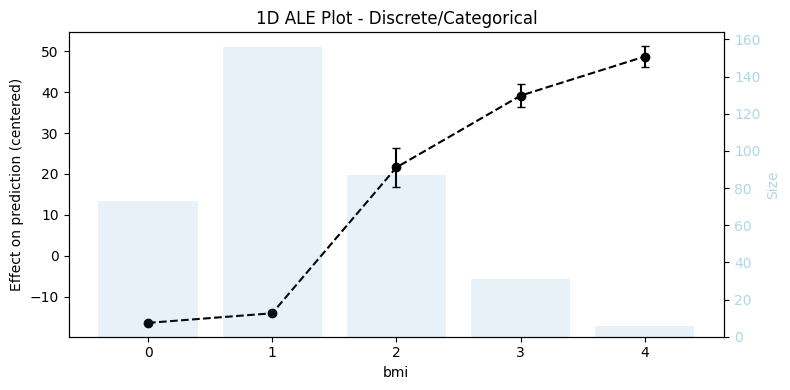

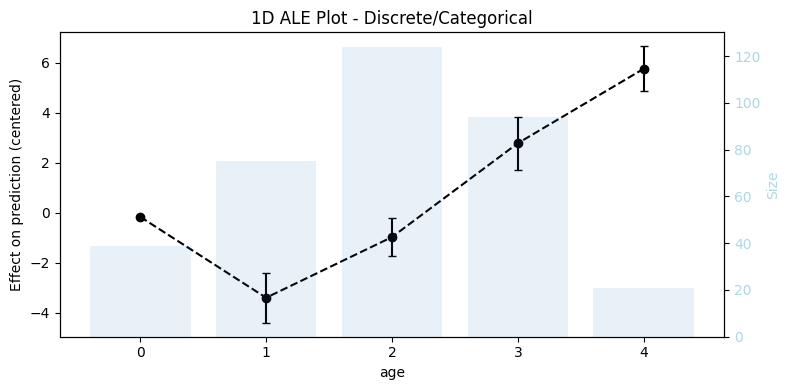

In [42]:
ale_bmi_b = ale(X=X_train_b, model=model_binned, feature=["bmi"])
ale_age_b = ale(X=X_train_b, model=model_binned, feature=["age"])

## Explanation
After binning the feature into 5 groups, the ALE plot becomes discrete: instead of a smooth curve we now get one effect value per bin, shown as dots with error bars. Comparing it to the original continuous plot, the direction is unchanged — the effect still rises across the bins — but the shape has gone from a smooth curve to a coarse staircase, and the magnitude has shrunk slightly (the highest BMI values got pooled into bin 4, so the peak effect is lower than in the continuous plot). Reading the binned plot: bin 1 has the lowest effect, meaning that group lowers the predicted progression the most, while bin 4 boosts it the most — though bin 4 contains few samples (short blue bar), so that estimate is less certain. The blue bars show how many data points fall in each bin. Overall, binning made the plot simpler and easier to read, but at the cost of losing the fine-grained detail the continuous ALE captured.


## (Optional) Exercise
**Note:**I created this exercise, but I am not sure how much doable it is for students (though I have solution). So, if someone tried it and have suggestion please let me know.

In this exercise, you will implement a basic ALE algorithm using Python. You will also explore the impact of different binning strategies on the ALE computation and assess various factors such as accuracy, computational efficiency, and ease of implementation.

1. Implement a Basic ALE Algorithm: Implement a function that calculates the ALE for a single continuous feature. Use the provided synthetic dataset for testing your function.

2. Experiment with Binning Strategies: Investigate how different binning strategies (equal-width, equal-frequency, and custom bins) affect the ALE calculation. Discuss the trade-offs in terms of accuracy, computational efficiency, and implementation complexity.

3. Testing and Validation: Write tests to validate the correctness of your ALE implementation. Check if the accumulated effects increase monotonically for synthetic linear relationships.

Dataset
A synthetic dataset is provided below for you to use in this exercise.


In [ ]:
# Synthetic Dataset Generation
import numpy as np
import pandas as pd

np.random.seed(0)
X = np.random.uniform(0, 1, size=(100, 1))
y = 3 * X.squeeze() + np.random.normal(0, 0.1, size=100)

data = pd.DataFrame({'Feature': X.squeeze(), 'Target': y})
data.head()

In [ ]:
# ALE Algorithm Implementation
def calculate_ale(feature_values, model_predictions, n_bins=10):
    # Ensure feature_values are sorted


    # Compute the bin edges and intervals


    # Calculate the ALE values per bin


        # Calculate the differences within each bin


        # Calculate the accumulated effect


    # Get the center of each bin


    return bin_centers, ale_effects



In [ ]:
# Test the function with a linear model
from sklearn.linear_model import LinearRegression

# Create a simple linear model
model = LinearRegression()
model.fit(data[['Feature']], data['Target'])

# Predictions from the model
predictions = model.predict(data[['Feature']])

# Calculate ALE
feature_centers, ale_effects = calculate_ale(data['Feature'].values, predictions)

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(feature_centers, ale_effects, marker='o')
plt.title('ALE Plot for the Feature')
plt.xlabel('Feature Value')
plt.ylabel('Accumulated Local Effect')
plt.grid(True)
plt.show()